In [3]:
import torch
import torch.nn as nn
import numpy as np
from TorchCRF import CRF

In [4]:
from gensim.models.fasttext import load_facebook_model

ft_model = load_facebook_model("crawl-300d-2M-subword.bin")

In [12]:
import json

def load_jsonl(path):

    tokens = []
    labels = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            tokens.append(obj["tokens"])
            labels.append(obj["labels"])

    return tokens, labels


train_tokens, train_labels = load_jsonl("train_data.jsonl")
val_tokens, val_labels     = load_jsonl("val_data.jsonl")

In [13]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

vocab = {PAD_TOKEN:0, UNK_TOKEN:1}

for sent in train_tokens:
    for tok in sent:
        if tok not in vocab:
            vocab[tok] = len(vocab)

PAD_ID = vocab[PAD_TOKEN]

import numpy as np

embedding_dim = 300
embedding_matrix = np.zeros((len(vocab), embedding_dim), dtype=np.float32)

for word, idx in vocab.items():
    if word == PAD_TOKEN:
        continue
    embedding_matrix[idx] = ft_model.wv.get_vector(word)

In [14]:
tag2id = {}

for seq in train_labels:
    for tag in seq:
        if tag not in tag2id:
            tag2id[tag] = len(tag2id)

id2tag = {v:k for k,v in tag2id.items()}

print(tag2id)

{'O': 0, 'B-LOC': 1, 'I-LOC': 2}


In [15]:
UNK_ID = vocab[UNK_TOKEN]

def encode_tokens(sentences):
    return [[vocab.get(tok, UNK_ID) for tok in s] for s in sentences]

def encode_labels(labels):
    return [[tag2id[t] for t in s] for s in labels]


train_ids = encode_tokens(train_tokens)
train_tag_ids = encode_labels(train_labels)

val_ids = encode_tokens(val_tokens)
val_tag_ids = encode_labels(val_labels)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class NERDataset(Dataset):
    def __init__(self, token_ids, tag_ids):
        self.token_ids = token_ids
        self.tag_ids = tag_ids
    
    def __len__(self):
        return len(self.token_ids)
    
    def __getitem__(self, idx):
        return {
            'token_ids': torch.tensor(self.token_ids[idx], dtype=torch.long),
            'tag_ids': torch.tensor(self.tag_ids[idx], dtype=torch.long)
        }

def collate_fn(batch):
    token_seqs = [item['token_ids'] for item in batch]
    tag_seqs = [item['tag_ids'] for item in batch]
    
    token_padded = pad_sequence(token_seqs, batch_first=True, padding_value=0)
    
    tag_padded = pad_sequence(tag_seqs, batch_first=True, padding_value=-100)
    
    mask = (token_padded != 0).float()
    
    return {
        'token_ids': token_padded,
        'tag_ids': tag_padded,
        'mask': mask,
        'lengths': torch.tensor([len(seq) for seq in token_seqs])
    }

train_dataset = NERDataset(train_ids, train_tag_ids)
val_dataset = NERDataset(val_ids, val_tag_ids)

batch_size = 32

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=collate_fn
)

for batch in train_loader:
    print("Token IDs shape:", batch['token_ids'].shape)  # (batch_size, max_seq_len)
    print("Tag IDs shape:", batch['tag_ids'].shape)      # (batch_size, max_seq_len)
    print("Mask shape:", batch['mask'].shape)            # (batch_size, max_seq_len)
    print("Lengths:", batch['lengths'])                   # (batch_size,)
    print("\nSample batch:")
    print("Tokens:\n", batch['token_ids'][0])
    print("Tags:\n", batch['tag_ids'][0])
    print("Mask:\n", batch['mask'][0])
    break

Token IDs shape: torch.Size([32, 63])
Tag IDs shape: torch.Size([32, 63])
Mask shape: torch.Size([32, 63])
Lengths: tensor([51, 36, 46, 21, 53, 46, 28, 17, 63, 47, 13, 56, 45, 40, 30, 37, 38, 50,
        43, 24, 44, 52, 48, 58,  5, 43, 24,  6, 20,  3, 41, 47])

Sample batch:
Tokens:
 tensor([   2,  528,  992,  529, 2316,  292,  718,   25,  139,  242,   16, 2887,
          35, 2260,   13,  921,  777, 2888,  186,  291,   35, 2889,  143,  393,
        2227, 2449, 2316,   35, 2890, 2891,   89, 2892, 2893,   35,  992, 1511,
        2894, 2473,   35, 1160,   25,  389,   33,  242, 2895, 2574,   75,   19,
        2896,   35, 2897,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0])
Tags:
 tensor([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    

In [ ]:
import torch
import torch.nn as nn

class ManualCRF(nn.Module):
    def __init__(self, num_tags):
        super(ManualCRF, self).__init__()
        self.num_tags = num_tags
        
        self.transitions = nn.Parameter(torch.randn(num_tags + 2, num_tags + 2))
        
        self.START_TAG = num_tags  
        self.END_TAG = num_tags + 1  
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.xavier_uniform_(self.transitions)
        
        self.transitions.data[:, self.START_TAG] = -10000
        self.transitions.data[self.END_TAG, :] = -10000
        self.transitions.data[self.START_TAG, self.END_TAG] = -10000
    
    def _forward_algorithm(self, emissions, mask):
        """
        Compute partition function (log sum exp over all possible tag sequences)
        Args:
            emissions: (batch_size, seq_len, num_tags)
            mask: (batch_size, seq_len) - float tensor (1 for real, 0 for padding)
        """
        batch_size, seq_len, num_tags = emissions.shape
        
        alpha = self.transitions[self.START_TAG, :num_tags].unsqueeze(0) + emissions[:, 0]
        
        for t in range(1, seq_len):
            current_mask = mask[:, t].unsqueeze(1)
            
            emissions_t = emissions[:, t].unsqueeze(1)
            expand_alpha = alpha.unsqueeze(2)
            transition_scores = self.transitions[:num_tags, :num_tags].unsqueeze(0)
            
            scores = expand_alpha + transition_scores + emissions_t
            new_alpha = torch.logsumexp(scores, dim=1)
            
            alpha = current_mask * new_alpha + (1 - current_mask) * alpha
        
        alpha = alpha + self.transitions[:num_tags, self.END_TAG].unsqueeze(0)
        
        partition = torch.logsumexp(alpha, dim=1)
        return partition
    
    def _score_sentence(self, emissions, tags, mask):
        batch_size, seq_len, _ = emissions.shape
        score = torch.zeros(batch_size, device=emissions.device)
        
        score += self.transitions[self.START_TAG, tags[:, 0]] + emissions[torch.arange(batch_size), 0, tags[:, 0]]
        
        for t in range(1, seq_len):
            curr_mask = mask[:, t]
            t_score = self.transitions[tags[:, t-1], tags[:, t]]
            e_score = emissions[torch.arange(batch_size), t, tags[:, t]]
            
            score += (t_score + e_score) * curr_mask

        last_tag_indices = (mask.sum(1).long() - 1)
        last_tags = tags.gather(1, last_tag_indices.unsqueeze(1)).squeeze(1)
        score += self.transitions[last_tags, self.END_TAG]
        
        return score
    
    def forward(self, emissions, tags, mask, reduction='mean'):
        """
        Compute negative log-likelihood loss
        """
        batch_size = emissions.shape[0]
        
        tags_masked = tags.clone()
        tags_masked[tags == -100] = 0
        
        gold_score = self._score_sentence(emissions, tags_masked, mask)
        partition = self._forward_algorithm(emissions, mask)
        
        loss = partition - gold_score
        
        if reduction == 'mean':
            return loss.mean()
        elif reduction == 'sum':
            return loss.sum()
        else:
            return loss
    
    def decode(self, emissions, mask):
        """
        Viterbi decoding to find best tag sequence
        """
        batch_size, seq_len, num_tags = emissions.shape
        
        viterbi = torch.full((batch_size, num_tags), -10000., device=emissions.device)
        viterbi[:, :] = self.transitions[self.START_TAG, :num_tags] + emissions[:, 0]
        
        backpointers = []
        
        for t in range(1, seq_len):
            current_mask = mask[:, t].unsqueeze(1)
            
            viterbi_expand = viterbi.unsqueeze(2)
            transition_scores = self.transitions[:num_tags, :num_tags].unsqueeze(0)
            emissions_t = emissions[:, t].unsqueeze(1)
            
            scores = viterbi_expand + transition_scores + emissions_t
            best_scores, best_tags = scores.max(dim=1)
            
            viterbi = current_mask * best_scores + (1 - current_mask) * viterbi
            backpointers.append(best_tags)
        
        viterbi += self.transitions[:num_tags, self.END_TAG].unsqueeze(0)
        
        best_final_score, best_final_tag = viterbi.max(dim=1)
        
        best_paths = []
        for batch_idx in range(batch_size):
            path_length = int(mask[batch_idx].sum().item())
            best_path = [best_final_tag[batch_idx].item()]
            
            for t in range(path_length - 2, -1, -1):
                best_path.insert(0, backpointers[t][batch_idx, best_path[0]])
            
            best_paths.append(best_path)
        
        return best_paths


class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, tag_size, embedding_matrix, hidden_dim=256, 
                 num_layers=1, dropout=0.5, embedding_dim=300):
        super(BiLSTM_CRF, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.tag_size = tag_size
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding.from_pretrained(
            embeddings=embedding_matrix,
            freeze=False,
            padding_idx=0
        )
        
        self.bilstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout)
        
        self.hidden2tag = nn.Linear(hidden_dim * 2, tag_size)
        
        self.crf = ManualCRF(tag_size)
    
    def _get_emissions(self, token_ids):
        """emission scores from BiLSTM"""
        embeddings = self.dropout(self.embedding(token_ids))
        lstm_out, _ = self.bilstm(embeddings)
        lstm_out = self.dropout(lstm_out)
        emissions = self.hidden2tag(lstm_out)
        return emissions
    
    def forward(self, token_ids, mask=None):
        """Forward pass"""
        emissions = self._get_emissions(token_ids)
        if mask is None:
            mask = (token_ids != 0).float()
        return self.crf.decode(emissions, mask)
    
    def loss(self, token_ids, tag_ids, mask=None):
        """CRF loss for training"""
        emissions = self._get_emissions(token_ids)
        if mask is None:
            mask = (token_ids != 0).float()
        return self.crf(emissions, tag_ids, mask, reduction='mean')

Using device: cpu

Training BiLSTM+CRF with 1 layer(s)

Epoch 1/20


Validating: 100%|██████████| 22/22 [00:00<00:00, 27.85it/s]


Train Loss: 16.4344 | Val Loss: 12.3647

Epoch 2/20


Validating: 100%|██████████| 22/22 [00:00<00:00, 30.06it/s]


Train Loss: 10.0235 | Val Loss: 8.6111

Epoch 3/20


...

Train Loss: 1.5864 | Val Loss: 4.0818

Epoch 19/20


Validating: 100%|██████████| 22/22 [00:01<00:00, 16.12it/s]


Train Loss: 1.5073 | Val Loss: 4.2113

Epoch 20/20


Validating: 100%|██████████| 22/22 [00:01<00:00, 13.98it/s]


Train Loss: 1.4484 | Val Loss: 4.2280


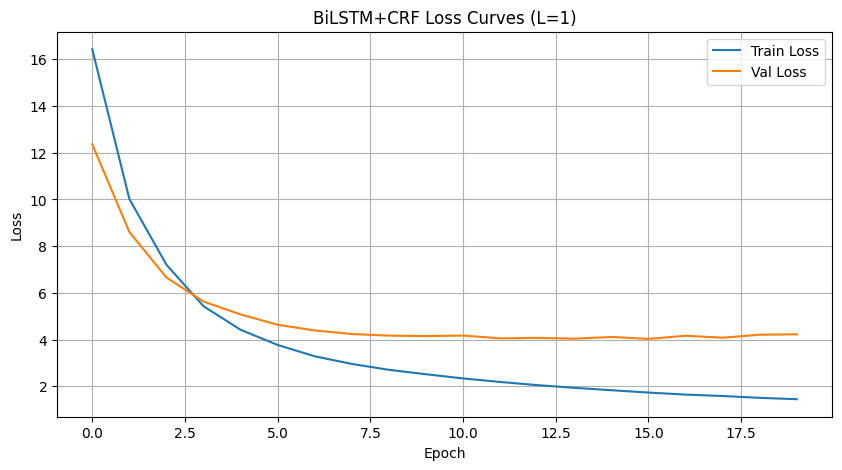

Model saved as bilstm_crf_L1.pt

Training BiLSTM+CRF with 2 layer(s)

Epoch 1/20


Validating: 100%|██████████| 22/22 [00:01<00:00, 12.65it/s]


Train Loss: 17.7769 | Val Loss: 13.2544

Epoch 2/20


Validating: 100%|██████████| 22/22 [00:02<00:00, 10.41it/s]


Train Loss: 11.3556 | Val Loss: 9.7597

Epoch 3/20


...

Train Loss: 1.3189 | Val Loss: 4.9671

Epoch 19/20


Validating: 100%|██████████| 22/22 [00:01<00:00, 13.43it/s]


Train Loss: 1.2535 | Val Loss: 5.0201

Epoch 20/20


Validating: 100%|██████████| 22/22 [00:01<00:00, 12.59it/s]


Train Loss: 1.1927 | Val Loss: 4.9914


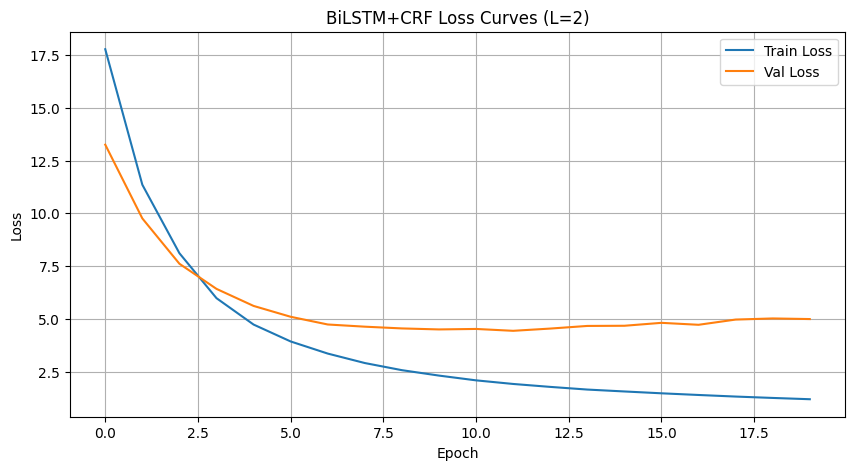

Model saved as bilstm_crf_L2.pt

Training BiLSTM+CRF with 3 layer(s)

Epoch 1/20


Validating: 100%|██████████| 22/22 [00:01<00:00, 11.72it/s]


Train Loss: 34.6297 | Val Loss: 17.2384

Epoch 2/20


Validating: 100%|██████████| 22/22 [00:01<00:00, 11.92it/s]


Train Loss: 14.2769 | Val Loss: 11.6002

Epoch 3/20


...

Train Loss: 1.6361 | Val Loss: 6.2897

Epoch 19/20


Validating: 100%|██████████| 22/22 [00:01<00:00, 11.16it/s]


Train Loss: 1.5350 | Val Loss: 6.3027

Epoch 20/20


Validating: 100%|██████████| 22/22 [00:01<00:00, 11.51it/s]


Train Loss: 1.4641 | Val Loss: 6.1845


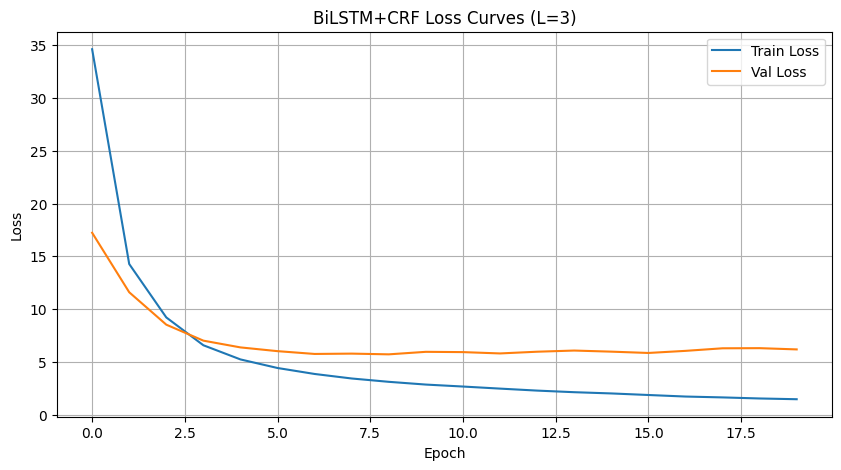

Model saved as bilstm_crf_L3.pt

Training complete for all configurations!


In [ ]:
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch in tqdm(dataloader, desc="Training"):
        token_ids = batch['token_ids'].to(device)
        tag_ids = batch['tag_ids'].to(device)
        mask = batch['mask'].to(device)
        
        optimizer.zero_grad()
        
        loss = model.loss(token_ids, tag_ids, mask)
        
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def validate_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            token_ids = batch['token_ids'].to(device)
            tag_ids = batch['tag_ids'].to(device)
            mask = batch['mask'].to(device)
            
            loss = model.loss(token_ids, tag_ids, mask)
            total_loss += loss.item()
    
    return total_loss / len(dataloader)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

hidden_dim = 64
dropout = 0
learning_rate = 0.0001
batch_size = 32
num_epochs = 20

results = {}

for L in [1, 2, 3]:
    print(f"\n{'='*50}")
    print(f"Training BiLSTM+CRF with {L} layer(s)")
    print(f"{'='*50}")
    
    model = BiLSTM_CRF(
        vocab_size=len(vocab),
        tag_size=len(tag2id),
        embedding_matrix=embedding_matrix,
        hidden_dim=hidden_dim,
        num_layers=L,
        dropout=dropout,
        embedding_dim=300
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    
    train_dataset = NERDataset(train_ids, train_tag_ids)
    val_dataset = NERDataset(val_ids, val_tag_ids)
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        collate_fn=collate_fn
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss = train_epoch(model, train_loader, optimizer, device)
        val_loss = validate_epoch(model, val_loader, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    results[L] = {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses
    }
    
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'BiLSTM+CRF Loss Curves (L={L})')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'loss_curves_L{L}.png')
    plt.show()
    
    torch.save({
        'epoch': num_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'hidden_dim': hidden_dim,
        'num_layers': L,
        'tag2id': tag2id,
        'id2tag': id2tag,
        'vocab': vocab
    }, f'bilstm_crf_L{L}.pt')
    
    print(f"Model saved as bilstm_crf_L{L}.pt")


EVALUATION RESULTS


Evaluating: 100%|██████████| 22/22 [00:01<00:00, 14.24it/s]



L=1 Results:
  Strict EM: 0.4246
  FreeMatch-F1: 0.8768
  Precision: 0.9302
  Recall: 0.8291


Evaluating: 100%|██████████| 22/22 [00:01<00:00, 12.40it/s]



L=2 Results:
  Strict EM: 0.4290
  FreeMatch-F1: 0.8952
  Precision: 0.9315
  Recall: 0.8617


Evaluating: 100%|██████████| 22/22 [00:01<00:00, 11.36it/s]



L=3 Results:
  Strict EM: 0.3895
  FreeMatch-F1: 0.8646
  Precision: 0.9150
  Recall: 0.8194

FINAL RESULTS TABLE
| Layers (L) | FreeMatch-F1 | Strict EM |
|------------|--------------|-----------|
| 1 | 0.8768 | 0.4246 |
| 2 | 0.8952 | 0.4290 |
| 3 | 0.8646 | 0.3895 |


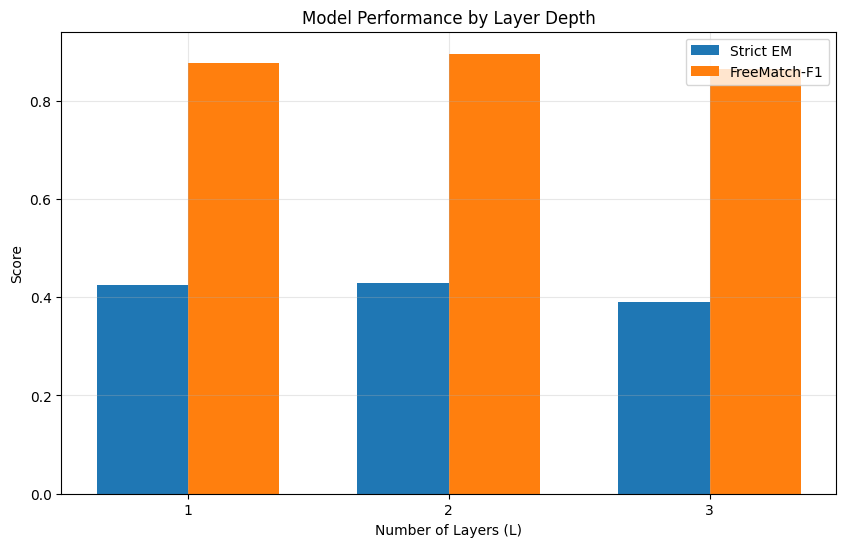

In [ ]:
from collections import Counter
import numpy as np

def compute_metrics(model, dataloader, device, id2tag, tag2id):
    """
    Compute FreeMatch-F1 and Strict EM
    """
    model.eval()
    
    all_true_tags = []
    all_pred_tags = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            token_ids = batch['token_ids'].to(device)
            tag_ids = batch['tag_ids'].to(device)
            mask = batch['mask'].to(device)
            
            predicted_sequences = model(token_ids, mask)
            
            for i in range(len(tag_ids)):
                seq_len = int(mask[i].sum().item())
                
                true_tags = tag_ids[i][:seq_len].cpu().tolist()
                
                pred_tags = predicted_sequences[i]
                pred_tags_clean = []
                for t in pred_tags:
                    if isinstance(t, torch.Tensor):
                        pred_tags_clean.append(t.item())
                    else:
                        pred_tags_clean.append(t)
                
                true_tag_names = [id2tag[t] for t in true_tags]
                pred_tag_names = [id2tag[t] for t in pred_tags_clean]
                
                all_true_tags.append(true_tag_names)
                all_pred_tags.append(pred_tag_names)
    
    strict_em = calculate_strict_em(all_true_tags, all_pred_tags)
    
    free_f1 = calculate_freematch_f1(all_true_tags, all_pred_tags)
    
    return {
        'strict_em': strict_em,
        'free_f1': free_f1,
        'num_samples': len(all_true_tags)
    }

def calculate_strict_em(true_sequences, pred_sequences):
    """
    Strict Exact Match: entire sequence must match exactly
    """
    correct = 0
    total = len(true_sequences)
    
    for true_seq, pred_seq in zip(true_sequences, pred_sequences):
        if true_seq == pred_seq:
            correct += 1
    
    return correct / total if total > 0 else 0

def calculate_freematch_f1(true_sequences, pred_sequences):
    """
    FreeMatch-F1: F1 score over all predicted spans
    """
    all_true_spans = []
    all_pred_spans = []
    
    for true_seq, pred_seq in zip(true_sequences, pred_sequences):
        true_spans = extract_entity_spans(true_seq)
        all_true_spans.extend(true_spans)
        
        pred_spans = extract_entity_spans(pred_seq)
        all_pred_spans.extend(pred_spans)
    
    true_counter = Counter(all_true_spans)
    pred_counter = Counter(all_pred_spans)
    
    true_positives = sum((pred_counter & true_counter).values())
    
    total_predicted = len(all_pred_spans)
    
    total_true = len(all_true_spans)
    
    precision = true_positives / total_predicted if total_predicted > 0 else 0
    recall = true_positives / total_true if total_true > 0 else 0
    
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

def extract_entity_spans(tag_sequence):
    """
    Extract entity spans from BIO tag sequence
    Returns list of (entity_type, start, end) tuples
    """
    spans = []
    i = 0
    while i < len(tag_sequence):
        tag = tag_sequence[i]
        
        if tag.startswith('B-'):
            entity_type = tag[2:]  
            start = i
            i += 1
            
            while i < len(tag_sequence) and tag_sequence[i] == f'I-{entity_type}':
                i += 1
            
            end = i - 1
            spans.append((entity_type, start, end))
        else:
            i += 1
    
    return spans

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)

results_table = []

for L in [1, 2, 3]:
    checkpoint = torch.load(f'bilstm_crf_L{L}.pt', map_location=device)
    
    model = BiLSTM_CRF(
        vocab_size=len(vocab),
        tag_size=len(tag2id),
        embedding_matrix=embedding_matrix,
        hidden_dim=checkpoint['hidden_dim'],
        num_layers=L,
        dropout=0,
        embedding_dim=300
    ).to(device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    
    val_dataset = NERDataset(val_ids, val_tag_ids)
    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        collate_fn=collate_fn
    )
    
    metrics = compute_metrics(model, val_loader, device, id2tag, tag2id)
    
    results_table.append({
        'L': L,
        'Strict EM': f"{metrics['strict_em']:.4f}",
        'FreeMatch-F1': f"{metrics['free_f1']['f1']:.4f}",
        'Precision': f"{metrics['free_f1']['precision']:.4f}",
        'Recall': f"{metrics['free_f1']['recall']:.4f}"
    })
    
    print(f"\nL={L} Results:")
    print(f"  Strict EM: {metrics['strict_em']:.4f}")
    print(f"  FreeMatch-F1: {metrics['free_f1']['f1']:.4f}")
    print(f"  Precision: {metrics['free_f1']['precision']:.4f}")
    print(f"  Recall: {metrics['free_f1']['recall']:.4f}")

print("\n" + "="*50)
print("FINAL RESULTS TABLE")
print("="*50)
print("| Layers (L) | FreeMatch-F1 | Strict EM |")
print("|------------|--------------|-----------|")
for row in results_table:
    print(f"| {row['L']} | {row['FreeMatch-F1']} | {row['Strict EM']} |")

plt.figure(figsize=(10, 6))
L_values = [1, 2, 3]
em_scores = [float(r['Strict EM']) for r in results_table]
f1_scores = [float(r['FreeMatch-F1']) for r in results_table]

x = np.arange(len(L_values))
width = 0.35

plt.bar(x - width/2, em_scores, width, label='Strict EM')
plt.bar(x + width/2, f1_scores, width, label='FreeMatch-F1')

plt.xlabel('Number of Layers (L)')
plt.ylabel('Score')
plt.title('Model Performance by Layer Depth')
plt.xticks(x, L_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('performance_comparison.png')
plt.show()